# Analyse business — Marketplace Olist

Ce dataset est issu du marché brésilien. Suite à une baisse de satisfaction client signalée par la direction marketing, nous avons formulé 3 hypothèses :

- Service client dégradé → visible dans les notes et commentaires clients
- Qualité vendeurs en baisse → visible dans les notes par vendeur et le taux de retours
- Délais de livraison qui s'allongent → visible dans l'écart entre date de commande et date de livraison

**Questions analysées :**
1. Les commandes en retard sont-elles corrélées aux notes les plus basses ?
2. Quelle est l'origine des retards — vendeur vs transporteur vs Olist — via `order_approved_at` et `order_delivered_carrier_date` ?
3. La satisfaction varie-t-elle selon la catégorie de produit ?
4. Visualisations : scatter retard vs note, bar chart par catégorie, line chart satisfaction mensuelle

In [ ]:
import pandas as pd


orders = pd.read_csv('archive/OlistMarket/olist_orders_dataset.csv')
reviews = pd.read_csv('archive/OlistMarket/olist_order_reviews_dataset.csv')
reviews.columns.tolist()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [14]:
orders.columns.tolist()


['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

## Jointure des datasets — isolation des commandes livrées

In [2]:
orders_delivered = orders[orders['order_status'] == 'delivered']
df = orders_delivered.merge(reviews, on='order_id', how='inner')
df.shape

(96361, 14)

## Calcul des métriques de délai

In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

delai_reel = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
retard = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

df['delai_reel'] = delai_reel
df['retard'] = retard

In [4]:
df['retard'].median()

-12.0

In [5]:
df['delai_reel'].describe()

count    96353.000000
mean        12.058472
std          9.462698
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delai_reel, dtype: float64

## Hypothèse 1 — Les commandes livrées avec plus de 12 jours de retard obtiennent une note moyenne de 1,7/5 contre 4,3/5 pour les commandes livrées à l'heure.

In [6]:
a_lheure = df[df['retard'] <= 0]['review_score']
en_retard = df[df['retard'] > 12]['review_score']

# 3. Compare
print("À l'heure :", a_lheure.mean().round(2))
print("Retard > 12j :", en_retard.mean().round(2))


À l'heure : 4.29
Retard > 12j : 1.71


In [12]:
# 1. Quantifie l'impact sur le business. "Augmenter les reviews à 4 étoiles" — ça représente quoi concrètement ? '
# 'Combien de commandes sont actuellement en retard de plus de 12 jours ? '
# 'C'est le nombre de clients insatisfaits que tu peux récupérer.
len(df[df['retard'] > 12])

1704

In [13]:
df['review_score'].mean()

np.float64(4.155716524320005)

## Travail 2 — Origine des retards : vendeur vs transporteur vs Olist

In [17]:
#Calculons deux metriques 
df['delai_vendeur'] = pd.to_datetime(df['order_delivered_carrier_date']) - pd.to_datetime(df['order_approved_at'])
df['delai_transporteur'] = pd.to_datetime(df['order_delivered_customer_date']) - pd.to_datetime(df['order_delivered_carrier_date'])

df['delai_vendeur'].describe()

count                        96345
mean     2 days 19:04:12.459837044
std      3 days 12:23:32.317073575
min            -172 days +18:44:38
25%                0 days 20:59:39
50%                1 days 19:36:43
75%                3 days 13:47:10
max              125 days 18:18:06
Name: delai_vendeur, dtype: object

In [18]:
df['delai_transporteur'].describe()

count                        96352
mean     9 days 07:11:03.206025821
std      8 days 16:15:18.423568084
min             -17 days +21:41:31
25%         4 days 02:20:40.750000
50%                7 days 02:19:08
75%               12 days 00:25:44
max              205 days 04:35:00
Name: delai_transporteur, dtype: object

## Travail 3 — Satisfaction par catégorie de produit

In [21]:
df_order_items = pd.read_csv('archive/OlistMarket/olist_order_items_dataset.csv')
df_products = pd.read_csv('archive/OlistMarket/olist_products_dataset.csv')
df_product_category_name_translation = pd.read_csv('archive/OlistMarket/product_category_name_translation.csv')


df_order_items_products = df_order_items.merge(df_products, on='product_id', how='inner')
df_products_category = df_order_items_products.merge(df_product_category_name_translation, on='product_category_name', how='inner')
df = df.merge(df_products_category, on='order_id', how='inner')


In [22]:
df.shape

(108458, 33)

In [23]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'delai_reel',
 'retard',
 'delai_vendeur',
 'delai_transporteur',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

⚠️ Limite : la review est au niveau commande. 
Une commande multi-produits réplique la même note 
sur chaque produit — biais potentiel sur les catégories 
à fort volume de produits par commande.

In [24]:
df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=True)

product_category_name_english
security_and_services        2.500000
diapers_and_hygiene          3.378378
office_furniture             3.517428
home_comfort_2               3.629630
fashion_male_clothing        3.758065
                               ...   
costruction_tools_tools      4.444444
books_imported               4.508772
books_general_interest       4.512195
cds_dvds_musicals            4.642857
fashion_childrens_clothes    5.000000
Name: review_score, Length: 71, dtype: float64

In [28]:
structured_type_categ = df.groupby('product_category_name_english')['review_score'].agg(
    review_median='median',
    review_moyen='mean',
    nb_commandes='count'
)

structured_type_filtered = structured_type_categ[structured_type_categ['nb_commandes'] > 100]
structured_type_filtered.sort_values(by='review_moyen', ascending=True)

,review_median,review_moyen,nb_commandes
product_category_name_english,,,
office_furniture,4.0,3.517428,1664
fashion_male_clothing,5.0,3.758065,124
fixed_telephony,4.0,3.758893,253
audio,5.0,3.830084,359
home_confort,5.0,3.851163,430
bed_bath_table,5.0,3.920983,10985
furniture_living_room,5.0,3.937247,494
furniture_decor,5.0,3.950116,8159
home_construction,5.0,3.959528,593


## Visualisations — Corrélation retard / satisfaction

### Scatter plot — Retard vs Note

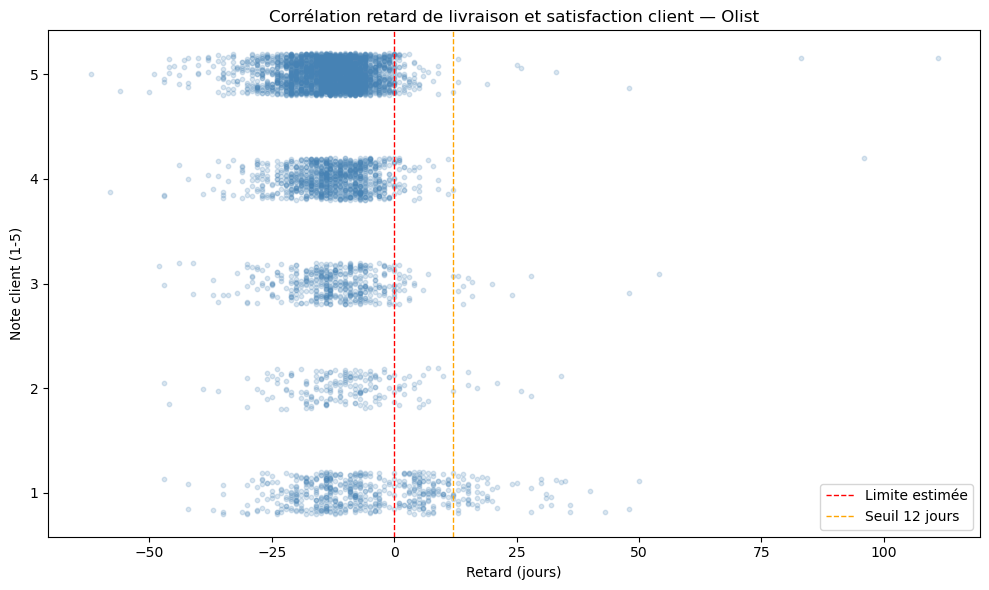

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# review_score ne vaut que 1-5 donc tous les points se superposent sur 5 lignes.
# Le jitter ajoute un petit bruit vertical pour révéler la densité réelle.
sample = df[df['retard'].notna()].sample(5000, random_state=42)
jitter = np.random.uniform(-0.2, 0.2, size=len(sample))

plt.figure(figsize=(10, 6))
plt.scatter(sample['retard'], sample['review_score'] + jitter,
            alpha=0.2, color='steelblue', s=10)
plt.axvline(x=0,  color='red',    linestyle='--', linewidth=1, label='Limite estimée')
plt.axvline(x=12, color='orange', linestyle='--', linewidth=1, label='Seuil 12 jours')
plt.xlabel("Retard (jours)")
plt.ylabel("Note client (1-5)")
plt.title("Corrélation retard de livraison et satisfaction client — Olist")
plt.legend()
plt.tight_layout()
plt.show()

### Insights

Les notes positives (4-5) se concentrent massivement autour des livraisons à l'heure ou en avance — c'est la confirmation visuelle de l'hypothèse. Mais on observe aussi un nuage de notes 1-2 côté gauche (retard ≤ 0), ce qui indique que **le retard n'est pas le seul facteur de mauvaise note** : la qualité produit joue également.

**Implication business :** deux leviers distincts à activer — (1) réduire les retards pour récupérer les 1 704 clients insatisfaits identifiés, (2) surveiller la qualité des produits même pour les commandes livrées à l'heure.

### Bar chart — Note moyenne par catégorie (top / flop 10)

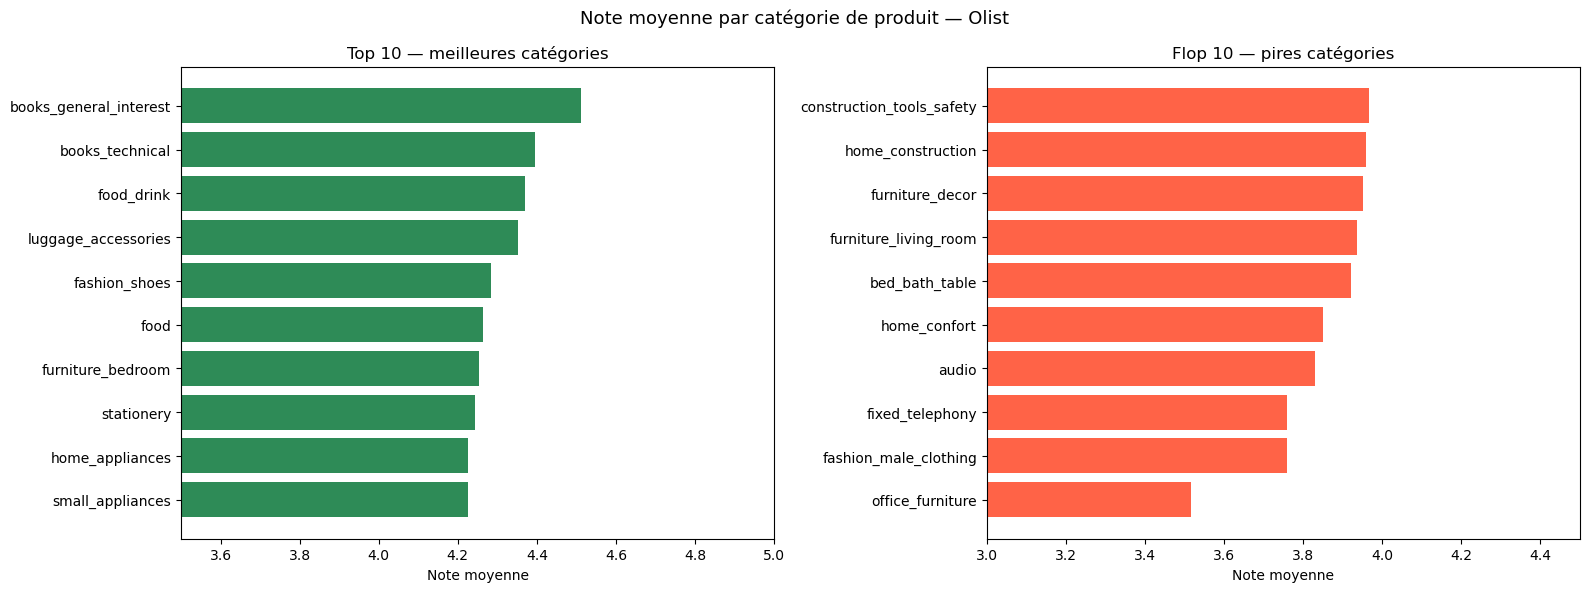

In [30]:
# top10 = 10 meilleures catégories par note, flop10 = 10 pires
top10  = structured_type_filtered.sort_values('review_moyen', ascending=True).tail(10)
flop10 = structured_type_filtered.sort_values('review_moyen', ascending=True).head(10)

# subplots(1, 2) = 1 ligne, 2 colonnes : deux graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(top10.index, top10['review_moyen'], color='seagreen')
ax1.set_xlim(3.5, 5)
ax1.set_title("Top 10 — meilleures catégories")
ax1.set_xlabel("Note moyenne")

ax2.barh(flop10.index, flop10['review_moyen'], color='tomato')
ax2.set_xlim(3, 4.5)
ax2.set_title("Flop 10 — pires catégories")
ax2.set_xlabel("Note moyenne")

plt.suptitle("Note moyenne par catégorie de produit — Olist", fontsize=13)
plt.tight_layout()
plt.show()

### Insights

Les catégories avec les meilleures notes (livres, alimentation, cosmétiques) sont aussi les plus légères et faciles à expédier. Les pires (mobilier, construction, bureautique) sont des produits volumineux ou fragiles — davantage exposés aux incidents de transport.

**Implication business :** la satisfaction est en partie structurelle : Olist devrait imposer des SLAs de livraison plus stricts sur les catégories lourdes, ou travailler avec des transporteurs spécialisés. Améliorer la logistique sur `office_furniture` (3,5/5, >1 600 commandes) aurait un impact immédiat visible.

### Line chart — Évolution mensuelle de la satisfaction

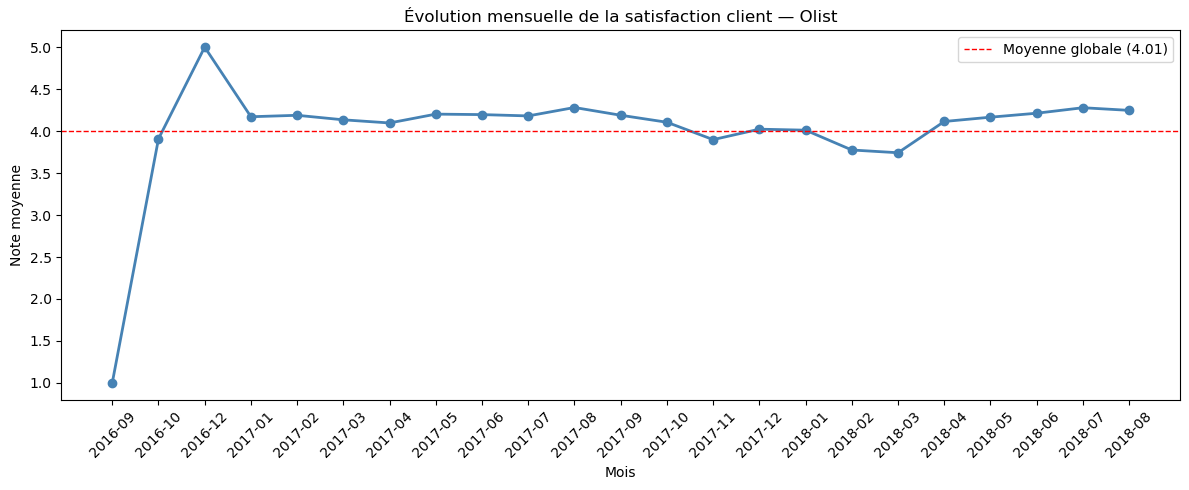

In [31]:
# dt.to_period('M') regroupe chaque date par mois (ex: 2018-01)
# On calcule la note moyenne par mois pour voir l'évolution dans le temps
monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['review_score'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly.index.astype(str), monthly.values,
         marker='o', color='steelblue', linewidth=2)
# Ligne rouge pointillée = moyenne globale sur toute la période
plt.axhline(y=monthly.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Moyenne globale ({monthly.mean():.2f})')
plt.xlabel("Mois")
plt.ylabel("Note moyenne")
plt.title("Évolution mensuelle de la satisfaction client — Olist")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Insights

Les notes de septembre-décembre 2016 (~5/5) sont statistiquement non fiables : Olist venait de lancer, le volume de commandes était infime — quelques avis suffisaient à faire monter la moyenne à 5. La vraie tendance commence à partir de mi-2017. La légère baisse observée début 2018 mérite surveillance, mais la moyenne se stabilise autour de 4,1 sur l'ensemble de la période.

**Implication business :** la satisfaction globale est correcte (4,1/5) mais ne s'améliore pas — elle stagne. Dans un marché concurrentiel, stagner équivaut à reculer. L'objectif devrait être de remonter structurellement au-dessus de 4,3 en s'attaquant aux retards et aux catégories flop identifiés.

In [32]:
(df['order_purchase_timestamp'].dt.to_period('M') == '2016-09').sum()

np.int64(3)

⚠️ Septembre 2016 : 3 commandes seulement — point non représentatif. L'analyse démarre réellement à partir de janvier 2017.